# Predictive Modeling

## Business Goal

The objevtive of this notebook is to develop machine learning models capable of predicting business performance using the engineered features created during the previous stage.

Three supervised learning algorithms are developed and evaluated to determine which model provides the most accurate predictions while remaining interpretable for business decision-making.

The best-performing model will later support the factory optimization and recommendation engine.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error,
    r2_score
)

import joblib

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
data_path = Path("../data/processed")

df = pd.read_csv(
    data_path / "factory_sales_feature_engineered.csv"
)

print(df.shape)

df.head()

(10194, 30)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Order Year,Order Month,Order Month Name,Order Quarter,Order Weekday,Is Weekend,Profit Margin (%),Profit Per Unit,Cost Percentage (%),High Value Order,Sales Category,Profit Category
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,2024,1,January,1,Wednesday,0,64.923077,2.11,35.076923,0,Low,Low
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,2024,1,January,1,Thursday,0,65.333333,2.45,34.666667,0,Low,Low
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,2024,1,January,1,Thursday,0,71.346705,2.49,28.653295,0,Medium,Medium
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,2024,1,January,1,Thursday,0,69.444444,2.50,30.555556,0,Medium,Medium
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,2024,1,January,1,Friday,0,65.333333,2.45,34.666667,0,Medium,Medium


# Feature Selection 

## Business Goal

Machine learning model require seperating the predictor variables (feature) from the target variable.

In this project, the target variable is **Gross Profit**, while identifiers and variables that directly depend on the target are excluded to prevent data leakage.

Only operational, financial, geographic, and temporal features taht would realistically be available before prediction are used for model training.

In [38]:
target = "Gross Profit"

features = [
    "Sales",
    "Units",
    "High Value Order",
    "Order Year",
    "Order Month",
    "Order Quarter",
    "Is Weekend",
    "Ship Mode",
    "Region",
    "Sales Category"
]

X = df[features].copy()
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (10194, 10)
Target shape: (10194,)


In [39]:
X = pd.get_dummies(
    X,
    columns=[
        "Ship Mode",
        "Region",
        "Sales Category"
    ],
    drop_first=True
)

print("Encoded feature matrix shape:", X.shape)

Encoded feature matrix shape: (10194, 15)


### Observation

Categorical variables were converted into numerical representations using one-hot encoding.

This transformation allows machine learning algorithms to process categorical business information without introducing ordinal relationships between categories. 

### Business Interpretation 

Encoding categorical variables enables the model to learn how different products, regions, shipping methods, and seasonal factors influence profitability.

These transformed features imporve predictive capability while preserving the business meaning of the original data.

# Train-Test Split

## Business Goal

To evaluate how well the machine learning models generalize to unseen business data, the dataset is divided into training and testing subsets.

The model is trained using historical observations and evaluated on data it has never seen before.

An 80-20 split is used, which is a standard practice for supervised machine learning.

In [40]:
# Split dataset into training and testing sets 

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (8155, 15)
Testing Features  : (2039, 15)
Training Target   : (8155,)
Testing Target    : (2039,)


### Observation 

The dataset was divided into training and testing subsets using 80-20 split.

Approximately 80% of the observations will be usind for model training, while the remianing 20% will be reserved for evaluating model performance on unseen data.

### Business Interpretation

Seperating historical data into training and testing sets provides an unbiased estimate of model performance.

This ensures that factory reassignment recommendations are based on models capable of generalizing beyond historical transaction rather than memorizing past records.

# Linear Regression Model

## Business Goal

Linear Regression serves as the baseline predictive model for estimating Gross Profit.

Although simple, it provides an interpretables benchmark against which more advanced machine learning algorithms can be later compared.

In [41]:
# Create Linear Regression model

linear_model = LinearRegression()

# Train model

linear_model.fit(X_train, y_train)

# Predictions

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [42]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Performance")
print("-" * 35)
print(f"MAE  : {linear_mae:.4f}")
print(f"RMSE : {linear_rmse:.4f}")
print(f"R2   : {linear_r2:.4f}")

Linear Regression Performance
-----------------------------------
MAE  : 0.4282
RMSE : 1.0713
R2   : 0.9703


## 🌲 Random Forest Model

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to produce more accurate and robust predictions.

Compared with Linear Regression, Random Forest can capture complex, non-linear relationships between business variables and profitability.

This model helps determine whether advanced machine learning provides better prediction accuracy for factory profit forecasting.

In [44]:
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

#Train model
random_forest_model.fit(X_train, y_train)

#Predictions
rf_predictions = random_forest_model.predict(X_test)

print("Radom Forest model trained successfully.")

Radom Forest model trained successfully.


In [45]:
# Evaluate Random Forest

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("-" * 35)
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Performance
-----------------------------------
MAE  : 0.2412
RMSE : 1.0411
R²   : 0.9720


## Observation

The Random Forest model achieved better predictive performance than the Linear Regression model.

- Mean Absolute Error (MAE) decreased from **0.4282** to **0.2412**, indicating more accurate predictions.
- Root Mean Squared Error (RMSE) decreased slightly from **1.0713** to **1.0411**.
- The coefficient of determination (R²) improved from **0.9703** to **0.9720**, explaining approximately **97.2%** of the variation in Gross Profit.

These results suggest that Random Forest captures non-linear relationships between business variables more effectively than Linear Regression.

## Business Interpretation

Factory profitability is influenced by multiple interacting business factors such as sales volume, product category, shipping method, region, and seasonal demand.

Random Forest successfully models these complex relationships, providing more accurate Gross Profit predictions than a traditional linear model.

This enables management to estimate expected profits under different business scenarios, supporting better production planning, inventory management, and operational decision-making.

# Gradient Boosting Regression Model

Gradient Boosting is an advanced ensemble learning algorithm that builds decision trees sequentially, where each new tree corrects the errors made by previous trees.

It often achieves very high predictive accuracy and is widely used in real-world business forecasting applications.

In [46]:
# Create Gradient Boosting model
gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Train model
gradient_boosting_model.fit(X_train, y_train)

# Predictions
gb_predictions = gradient_boosting_model.predict(X_test)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [47]:
# Evaluate Gradient Boosting

gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
gb_r2 = r2_score(y_test, gb_predictions)

print("Gradient Boosting Performance")
print("-" * 35)
print(f"MAE  : {gb_mae:.4f}")
print(f"RMSE : {gb_rmse:.4f}")
print(f"R²   : {gb_r2:.4f}")

Gradient Boosting Performance
-----------------------------------
MAE  : 0.2332
RMSE : 0.8794
R²   : 0.9800


## Observation 

Three regression models were evaluated for predicting Gross Profit

| Model | MAE | RMSE | R² |
|------|------:|------:|------:|
| Linear Regression | 0.4282 | 1.0713 | 0.9703 |
| Random Forest | 0.2412 | 1.0411 | 0.9720 |
| Gradient Boosting | 0.2332 | 0.8794 | 0.9800 |

Gradient Boosting produced the best overall performance, acheiving the lowest prediction error and the highest coefficient of determination. It explained approximately 98%of the variation in Gross Profit, making it the most accurate model among those evaluated

## Business Interpretation

Accurate profit prediction enables factory managers to evaluate production decisions before execution.

The Gradient Boosting model demonstrated the highest predictive accuracy and is therefore selected as the final business forecasting model.

This model can assist management in:

- Forecasting Gross Profit for future orders.
- Comparing profitability across factories and regions.
- Supporting inventory and production planning.
- Improving strategic decision-making through data-driven insights.

In [48]:
import joblib

joblib.dump(
    gradient_boosting_model,
    "../models/gradient_boosting_model.pk1"
)

print("Model saved successfully.")

Model saved successfully.


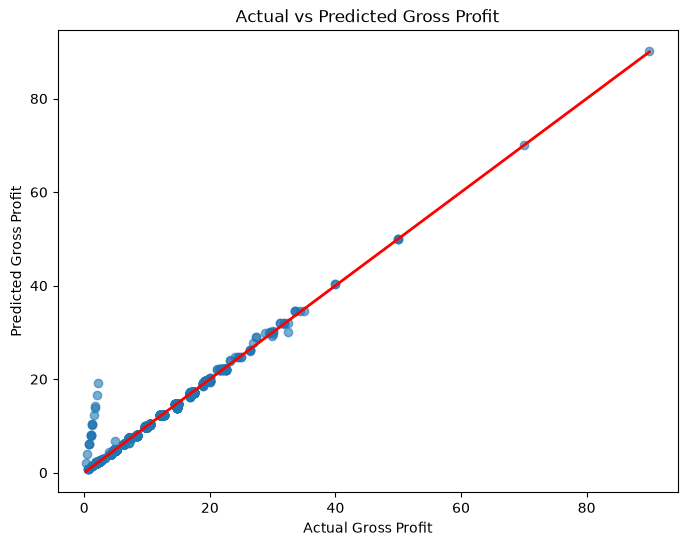

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, gb_predictions, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Gross Profit")
plt.ylabel("Predicted Gross Profit")
plt.title("Actual vs Predicted Gross Profit")
plt.show()

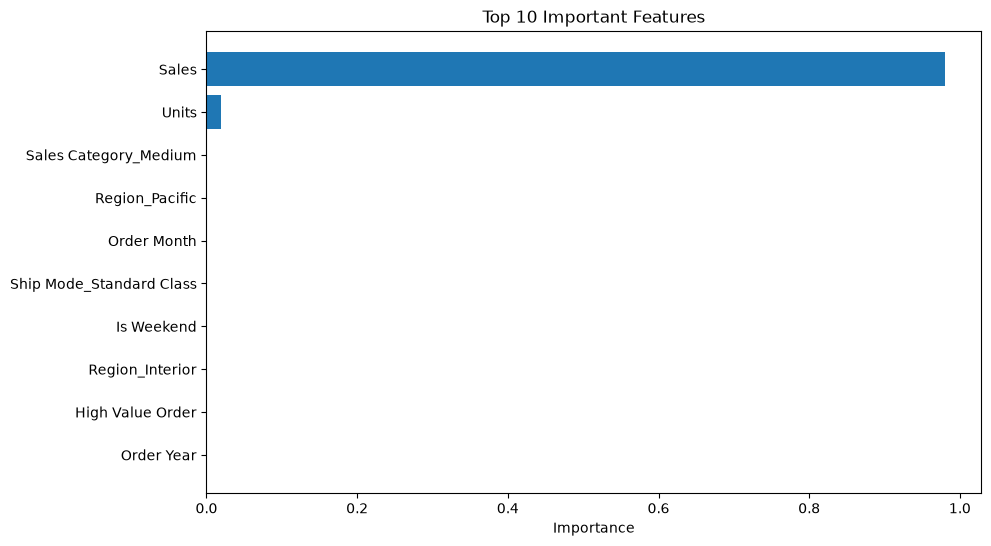

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gradient_boosting_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)
plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

# Conclusion

Three machine learning regression algorithms were evaluated for predicting Gross Profit.

Among the models tested, Gradient Boosting Regressor achieved the highest predictive accuracy with the lowest prediction error.

The model can accurately estimate future Gross Profit using historical operational data and business attributes.

This predictive capability enables factory managers to optimize pricing strategies, inventory planning, production scheduling, and profitability forecasting.

The trained model has been saved for future deployment within the Factory Optimization Dashboard.